Importing the Dataset

In [11]:
import pandas as pd
import numpy as np


In [12]:
path = "/content/adult.data"

In [13]:
df = pd.read_csv( path )
df_backup = pd.read_csv( path )

In [14]:
col_list = [ "age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income" ]

In [15]:
df.columns = col_list
df_backup.columns = col_list

Drop unnecessary columns

In [17]:
df = df.drop( "fnlwgt", axis=1 )

OneHotEncoding

In [18]:
#targeted_cols = [ "workclass", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]
targeted_cols = [ "workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country" ]

In [19]:
df = pd.get_dummies(df, columns=targeted_cols, dtype=int)

OrdinalEncoding ( skip for now )

In [20]:
#targeted_cols = [ "education" ]

In [ ]:
#edu_values = df[ "education" ].unique( )

#edu_map = {  }

Splitting into features and target

In [22]:
y = df[ "income" ]
X = df.drop( "income", axis=1 )

Splitting into test and train

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

Scaling Numeric data for X_train only

In [25]:
from sklearn.preprocessing import StandardScaler

In [27]:
for col in X_train :
  if( X[col].dtype == "int64" or X[col].dtype == "float64" ) :
    scaler = StandardScaler()
    X_train[col] = scaler.fit_transform( np.array(X_train[col]).reshape(-1,1) )


Importing KNN model

In [28]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
knn_model = KNeighborsClassifier( n_neighbors = 5 )

Importing DecisionTree model

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
dtc_model = DecisionTreeClassifier( max_depth=3 )

Fitting the models on the data

In [33]:
knn_model.fit( X_train, y_train )

KNeighborsClassifier()

In [34]:
dtc_model.fit( X_train, y_train )

DecisionTreeClassifier(max_depth=3)

Obtain predicted labels of the models

In [35]:
knn_pred = knn_model.predict( X_test )

In [36]:
dtc_pred = dtc_model.predict( X_test )

Obtain accuracy scores for the models

In [37]:
from sklearn.metrics import accuracy_score

In [38]:
knn_acc = accuracy_score( y_test, knn_pred )

In [39]:
dtc_acc = accuracy_score( y_test, dtc_pred )

In [44]:
print( f" KNN accuracy : { knn_acc }" )

 KNN accuracy : 0.7807125307125307


In [46]:
print( f" DTC accuracy : { dtc_acc }" )

 DTC accuracy : 0.7045454545454546


Plot pie chart for accuracy scores

In [40]:
import matplotlib.pyplot as plt

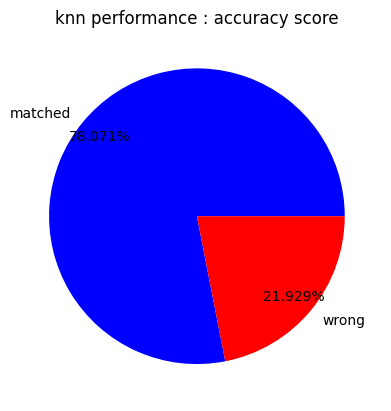

In [48]:
#plt.subplot( 1, 2, 1 )
plt.pie(
    x=[ knn_acc*100, 100 - (knn_acc)*100 ],
    labels=["matched", "wrong"],
    autopct='%1.3f%%',   # Formats the percentage to 1 decimal place
    colors=[ "blue", "red" ],       # Applies custom colors
    pctdistance=0.85     # Adjusts the position of the percentage text
)
plt.title( "knn performance : accuracy score" )

plt.show()


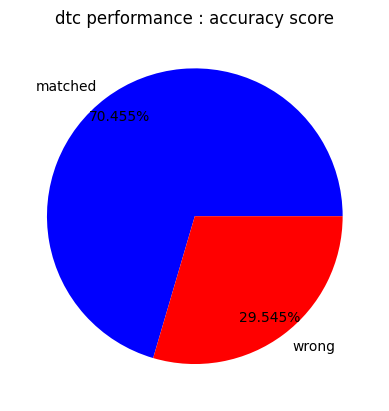

In [49]:
#plt.subplot( 1, 2, 2 )
plt.pie(
    x=[ dtc_acc, 1 - dtc_acc ],
    labels=["matched", "wrong"],
    autopct='%1.3f%%',   # Formats the percentage to 1 decimal place
    colors=[ "blue", "red" ],       # Applies custom colors
    pctdistance=0.85     # Adjusts the position of the percentage text
)
plt.title( "dtc performance : accuracy score" )

plt.show()